# Project 3 Part 4: Image Segmentation with U-Net

In this notebook, you will learn about semantic segmentation - the task of classifying every pixel in an image. You'll implement and train U-Net, a popular architecture for image segmentation.

## Learning Objectives:
- Understand the difference between classification, detection, and segmentation
- Learn about encoder-decoder architectures and skip connections
- Implement U-Net from scratch
- Train U-Net on a segmentation dataset
- Evaluate segmentation performance using IoU and Dice coefficient
- Visualize segmentation results

***NOTE:***
When filling in the code, please REMOVE the `pass` and `None` statement.
DO NOT remove the TODO coding highlight in your submission.

### <span style="color: red;"> Grading Criteria for This Notebook (Part 4):</span>

**1. Code Quality and Implementation (2 pts)**
- U-Net architecture correctly implemented (encoder, decoder, skip connections)
- COCO dataset loading and preprocessing
- Loss functions and metrics implementation
- Training loop functionality

**2. Performance Benchmarks (2 pts)**

Your model will be evaluated on the COCO validation subset (500 images, 11 classes):

**Minimum Requirements:**
- Test IoU ≥ 0.30 (30%) - **Required to pass**
- Test Dice Coefficient ≥ 0.35 (35%) - **Required to pass**
- Model successfully trains for at least 15 epochs without errors

**Performance Grading:**
- **Excellent (2.0 pts)**: Test IoU ≥ 0.45 AND Test Dice ≥ 0.50
- **Good (1.5 pts)**: Test IoU ≥ 0.40 AND Test Dice ≥ 0.45
- **Satisfactory (1.0 pts)**: Test IoU ≥ 0.35 AND Test Dice ≥ 0.40
- **Minimum (0.5 pts)**: Test IoU ≥ 0.30 AND Test Dice ≥ 0.35
- **Insufficient (0 pts)**: Below minimum requirements

*Note: COCO segmentation is challenging. These benchmarks account for training on a limited subset with 11 classes. Focus on correct implementation and understanding.*

**3. Analysis and Inline Questions (2 pts)**
- Thoughtful answers to all 5 question sections
- Analysis of segmentation results and error patterns
- Understanding of U-Net architecture and segmentation concepts

**Total for this notebook: 6 points**

**Tips for achieving good performance:**
- Train for 20-25 epochs
- Use learning rate of 1e-4 with Adam optimizer
- Consider using combined CrossEntropy + Dice Loss
- Ensure proper data augmentation
- Monitor training curves to avoid overfitting

In [5]:
# # Google Colab Setup (Comment out for local computer running)
################################################################################
# Uncomment and set the path to your project folder in Google Drive
################################################################################
# from google.colab import drive
# drive.mount('/content/drive')

# FOLDERNAME = 'cpsc8430/assignments/project3/'
# assert FOLDERNAME is not None, "[!] Enter the foldername."

# import sys
# sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))
# %cd /content/drive/My\ Drive/$FOLDERNAME

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import seaborn as sns

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

plt.rcParams['figure.figsize'] = (12, 8)

Using device: cpu


## Part 1: Understanding Image Segmentation

There are three main types of segmentation:
1. **Semantic Segmentation**: Classify each pixel into a category (all cats are labeled "cat")
2. **Instance Segmentation**: Distinguish between different instances (cat1, cat2, etc.)
3. **Panoptic Segmentation**: Combination of semantic and instance segmentation

In this notebook, we focus on **semantic segmentation**.

### Key Concepts:
- **Pixel-wise classification**: Each pixel gets a class label
- **Encoder-Decoder**: Encoder extracts features, decoder reconstructs spatial resolution
- **Skip connections**: Connect encoder and decoder layers to preserve spatial information
- **IoU (Intersection over Union)**: Measures overlap between predicted and ground truth masks
- **Dice Coefficient**: Similar to IoU, measures similarity between masks

### Question 1: Segmentation Fundamentals

**a) What is the key difference between semantic segmentation and object detection?**

$\color{blue}{\textit{Your Answer:}}$

Semantic segmentation fills in the object while object detection creates a box surrounding it.

**b) Why is semantic segmentation more challenging than image classification?**

$\color{blue}{\textit{Your Answer:}}$

The semantic segmentation must know what each pixel belongs to. This involves understanding where the object begins and ends.

**c) What is the difference between semantic and instance segmentation?**

$\color{blue}{\textit{Your Answer:}}$

Semantic is general, which means if there are multiple of the same class of objects it will highlight them all the same color. Instance segmentation discriminates between objects within the same class.

## Part 2: Implement U-Net Architecture

**TODO: Implement U-Net from scratch**

U-Net consists of:
1. **Contracting Path (Encoder)**: Series of conv + pooling layers that reduce spatial dimensions
2. **Bottleneck**: Deepest layer with smallest spatial dimensions
3. **Expanding Path (Decoder)**: Series of upsampling + conv layers that increase spatial dimensions
4. **Skip Connections**: Concatenate encoder features with decoder features at each level

In [16]:
class DoubleConv(nn.Module):
    """(Conv => BatchNorm => ReLU) * 2"""

    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        ################################################################################
        # TODO: Implement double convolution block
        # HINT: Two sequences of Conv2d -> BatchNorm2d -> ReLU
        # Use kernel_size=3, padding=1 to maintain spatial dimensions
        ################################################################################
        # *****START OF YOUR CODE*****
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        # *****END OF YOUR CODE*****
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO: Implement forward pass
        ################################################################################
        # *****START OF YOUR CODE*****
        return self.double_conv(x)
        # *****END OF YOUR CODE*****
        ################################################################################


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        ################################################################################
        # TODO: Implement downsampling block
        # HINT: MaxPool2d(2) followed by DoubleConv
        ################################################################################
        # *****START OF YOUR CODE*****
        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
        # *****END OF YOUR CODE*****
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO: Implement forward pass
        ################################################################################
        # *****START OF YOUR CODE*****
        return self.down(x)
        # *****END OF YOUR CODE*****
        ################################################################################


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()

        ################################################################################
        # TODO: Implement upsampling block
        # HINT:
        # Option 1 (bilinear=True): Use nn.Upsample with mode='bilinear'
        # Option 2 (bilinear=False): Use nn.ConvTranspose2d
        # Then apply DoubleConv to concatenated features
        # Note: After concatenation, input channels = in_channels + out_channels
        ################################################################################
        # *****START OF YOUR CODE*****
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)
        # *****END OF YOUR CODE*****
        ################################################################################

    def forward(self, x1, x2):
        """
        Args:
            x1: features from decoder (to be upsampled)
            x2: features from encoder (skip connection)
        """
        ################################################################################
        # TODO: Implement forward pass
        # HINT:
        # 1. Upsample x1
        # 2. Handle size mismatch between x1 and x2 if needed (padding)
        # 3. Concatenate x1 and x2 along channel dimension: torch.cat([x2, x1], dim=1)
        # 4. Apply double conv
        ################################################################################
        # *****START OF YOUR CODE*****
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)
        # *****END OF YOUR CODE*****
        ################################################################################


class OutConv(nn.Module):
    """Final 1x1 convolution to get class scores"""

    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=2, bilinear=True):
        """
        U-Net architecture

        Args:
            n_channels: Number of input channels (3 for RGB)
            n_classes: Number of output classes
            bilinear: Use bilinear upsampling (True) or transposed conv (False)
        """
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        ################################################################################
        # TODO: Build U-Net architecture
        # HINT: Standard U-Net structure:
        # Encoder:
        #   inc: DoubleConv(n_channels -> 64)
        #   down1: Down(64 -> 128)
        #   down2: Down(128 -> 256)
        #   down3: Down(256 -> 512)
        #   down4: Down(512 -> 1024)
        # Decoder:
        #   up1: Up(1024 -> 512)
        #   up2: Up(512 -> 256)
        #   up3: Up(256 -> 128)
        #   up4: Up(128 -> 64)
        #   outc: OutConv(64 -> n_classes)
        ################################################################################
        # *****START OF YOUR CODE*****
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        # Encoder:
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)

        # Decoder:
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)
        # *****END OF YOUR CODE*****
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO: Implement forward pass
        # HINT:
        # Encoder (save intermediate features for skip connections):
        #   x1 = self.inc(x)
        #   x2 = self.down1(x1)
        #   x3 = self.down2(x2)
        #   x4 = self.down3(x3)
        #   x5 = self.down4(x4)
        # Decoder (use skip connections):
        #   x = self.up1(x5, x4)
        #   x = self.up2(x, x3)
        #   x = self.up3(x, x2)
        #   x = self.up4(x, x1)
        #   logits = self.outc(x)
        ################################################################################
        # *****START OF YOUR CODE*****
        # Encoder:
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder:
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits
        # *****END OF YOUR CODE*****
        ################################################################################

    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Test U-Net
model = UNet(n_channels=3, n_classes=2)
print(f"U-Net architecture:\n{model}")
print(f"\nNumber of parameters: {model.get_num_parameters():,}")

# Test forward pass
sample_input = torch.randn(2, 3, 256, 256)
output = model(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")
print("Expected output shape: (2, 2, 256, 256)")

U-Net architecture:
UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (down): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), b

### Question 2: U-Net Architecture

**a) Explain the encoder-decoder architecture. What is the purpose of each part?**

$\color{blue}{\textit{Your Answer:}}$

The encoder is the CNN that creates a channelwise understanding of the context of the image. The decoder then takes the low res context and expands it to the image itself.

**b) What are skip connections in U-Net? Why are they important for segmentation?**

$\color{blue}{\textit{Your Answer:}}$

During encoding, spatial information is lost due to pooling. This means, by the time it reaches the decoder, the network as lost track of "where" the object is. The skip connection passes the feature information to the decoder.

**c) What is the difference between bilinear upsampling and transposed convolution? What are the pros and cons of each?**

$\color{blue}{\textit{Your Answer:}}$

Bilinear upsampling is a mathematical model. Transposed convolution is a learnable model. The former will be faster, but less accurate with certain patterns, while the latter will be slower but with higher accuracy with more complex patterns.

## Part 3: Load COCO Segmentation Dataset

We'll use the COCO (Common Objects in Context) dataset, which is a large-scale object detection, segmentation, and captioning dataset. It contains 80 object categories with pixel-level annotations.

**Dataset Reference:** [torchvision.datasets.CocoDetection](https://pytorch.org/vision/main/generated/torchvision.datasets.CocoDetection.html)

In [9]:
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import urllib.request
import zipfile
import json

class COCOSegmentation(Dataset):
    """
    COCO Dataset for semantic segmentation

    This dataset wraps the COCO dataset and converts instance segmentation
    annotations to semantic segmentation masks.
    """

    def __init__(self, root_dir, annotation_file, transform=None, mask_transform=None, max_samples=None):
        """
        Args:
            root_dir: Root directory containing COCO images
            annotation_file: Path to COCO annotation JSON file
            transform: Transform to apply to images
            mask_transform: Transform to apply to masks
            max_samples: Maximum number of samples to use (for faster training)
        """
        self.root_dir = root_dir
        self.coco = COCO(annotation_file)
        self.transform = transform
        self.mask_transform = mask_transform

        # Get all image IDs
        self.image_ids = list(self.coco.imgs.keys())

        # Limit number of samples if specified
        if max_samples is not None:
            self.image_ids = self.image_ids[:max_samples]

        # Get category IDs for segmentation (we'll use first 10 categories for simplicity)
        self.cat_ids = self.coco.getCatIds()[:10]

        # Filter images that have annotations for our categories
        valid_image_ids = []
        for img_id in self.image_ids:
            ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=self.cat_ids, iscrowd=False)
            if len(ann_ids) > 0:
                valid_image_ids.append(img_id)

        self.image_ids = valid_image_ids
     
    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        # Get image info
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Create empty mask
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

        # Get annotations for this image
        ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=self.cat_ids, iscrowd=False)
        anns = self.coco.loadAnns(ann_ids)

        # Create semantic segmentation mask
        for ann in anns:
            if 'segmentation' in ann:
                # Get category index (1-indexed, 0 is background)
                cat_id = ann['category_id']
                if cat_id in self.cat_ids:
                    cat_idx = self.cat_ids.index(cat_id) + 1

                    # Convert polygon or RLE to binary mask
                    if isinstance(ann['segmentation'], list):
                        # Polygon format
                        rles = coco_mask.frPyObjects(ann['segmentation'], img_info['height'], img_info['width'])
                        rle = coco_mask.merge(rles)
                    else:
                        # RLE format
                        rle = ann['segmentation']

                    # Decode RLE to binary mask
                    binary_mask = coco_mask.decode(rle)

                    # Add to semantic mask
                    mask[binary_mask > 0] = cat_idx

        # Convert to PIL Image for transforms
        mask = Image.fromarray(mask)

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)
        else:
            mask = transforms.ToTensor()(mask)

        # Convert mask to long tensor (class indices for CrossEntropyLoss)
        mask = (mask * 255).long()

        return image, mask


# Download and prepare COCO dataset (using a small subset for demonstration)
data_root = 'cpsc8430/datasets/coco'
os.makedirs(data_root, exist_ok=True)

# We'll use COCO 2017 validation set (smaller than train set)
coco_images_dir = os.path.join(data_root, 'val2017')
coco_annotations_file = os.path.join(data_root, 'annotations', 'instances_val2017.json')

# Check if COCO dataset exists
if not os.path.exists(coco_annotations_file):
    print("COCO dataset not found. Please download it manually:")
    print("1. Download validation images from: http://images.cocodataset.org/zips/val2017.zip")
    print("2. Download annotations from: http://images.cocodataset.org/annotations/annotations_trainval2017.zip")
    print("3. Extract to:", data_root)
    print("\nFor automatic download (this may take a while):")

    # Create directories
    os.makedirs(os.path.join(data_root, 'annotations'), exist_ok=True)

    # Download validation images
    val_images_url = 'http://images.cocodataset.org/zips/val2017.zip'
    val_images_zip = os.path.join(data_root, 'val2017.zip')

    if not os.path.exists(coco_images_dir):
        print("\nDownloading COCO validation images (~1GB)...")
        try:
            urllib.request.urlretrieve(val_images_url, val_images_zip)
            print("✓ Download complete!")

            print("Extracting images...")
            with zipfile.ZipFile(val_images_zip, 'r') as zip_ref:
                zip_ref.extractall(data_root)
            print("✓ Extraction complete!")

            os.remove(val_images_zip)
        except Exception as e:
            print(f"Error downloading images: {e}")
            print("Please download manually.")

    # Download annotations
    annotations_url = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
    annotations_zip = os.path.join(data_root, 'annotations_trainval2017.zip')

    if not os.path.exists(coco_annotations_file):
        print("\nDownloading COCO annotations (~241MB)...")
        try:
            urllib.request.urlretrieve(annotations_url, annotations_zip)
            print("✓ Download complete!")

            print("Extracting annotations...")
            with zipfile.ZipFile(annotations_zip, 'r') as zip_ref:
                zip_ref.extractall(data_root)
            print("✓ Extraction complete!")

            os.remove(annotations_zip)
        except Exception as e:
            print(f"Error downloading annotations: {e}")
            print("Please download manually.")
else:
    print("✓ COCO dataset already exists")

# Create dataset
print("\nLoading COCO dataset for segmentation...")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=Image.NEAREST),  # Use NEAREST for masks
    transforms.ToTensor(),
])

# Use max_samples to limit dataset size for faster training
dataset = COCOSegmentation(
    coco_images_dir,
    coco_annotations_file,
    transform=transform,
    mask_transform=mask_transform,
    max_samples=500  # Use 500 images for faster training
)

print(f"✓ Loaded {len(dataset)} images with segmentation annotations")

# Split into train and test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: 11 (background + 10 object categories)")

✓ COCO dataset already exists

Loading COCO dataset for segmentation...
loading annotations into memory...
Done (t=0.30s)
creating index...
index created!
✓ Loaded 283 images with segmentation annotations
Training samples: 226
Test samples: 57
Number of classes: 11 (background + 10 object categories)


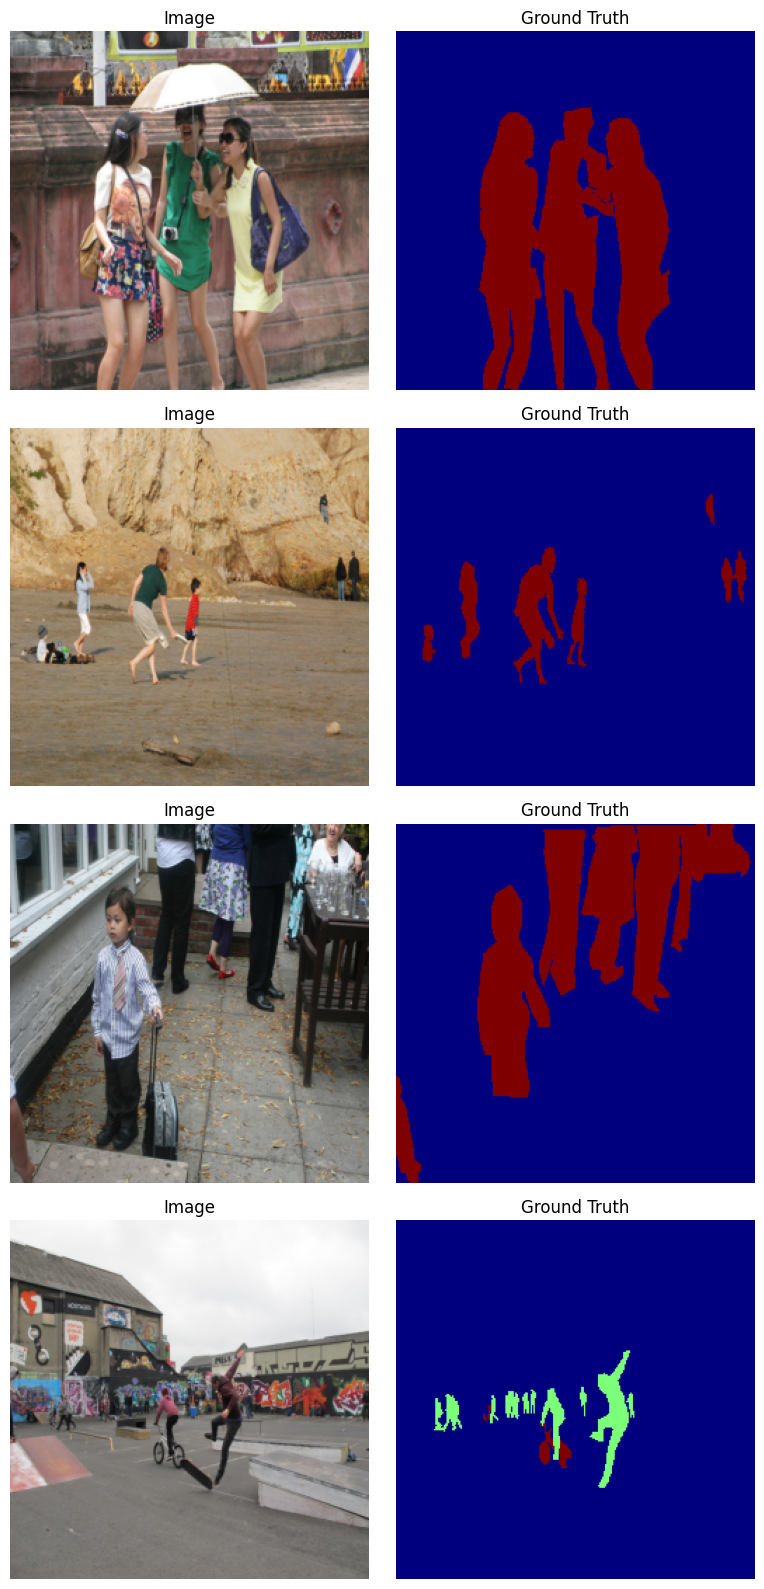

In [10]:
# Visualize some samples
def visualize_segmentation(images, masks, predictions=None, num_samples=4):
    """
    Visualize images, ground truth masks, and predictions
    """
    num_rows = num_samples
    num_cols = 3 if predictions is not None else 2

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4))

    for i in range(num_samples):
        # Image
        img = images[i].permute(1, 2, 0).cpu().numpy()
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Image')
        axes[i, 0].axis('off')

        # Ground truth mask
        mask = masks[i].squeeze().cpu().numpy()
        axes[i, 1].imshow(mask, cmap='jet')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        # Prediction
        if predictions is not None:
            pred = predictions[i].squeeze().cpu().numpy()
            axes[i, 2].imshow(pred, cmap='jet')
            axes[i, 2].set_title('Prediction')
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


# Get a batch and visualize
images, masks = next(iter(train_loader))
visualize_segmentation(images, masks, num_samples=4)

## Part 4: Loss Functions and Metrics

**TODO: Implement segmentation-specific loss functions and metrics**

In [11]:
class DiceLoss(nn.Module):
    """
    Dice Loss for segmentation
    Dice = 2 * |A ∩ B| / (|A| + |B|)
    Loss = 1 - Dice
    """

    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):
        """
        Args:
            predictions: (N, C, H, W) logits
            targets: (N, H, W) class indices
        """
        ################################################################################
        # TODO: Implement Dice Loss
        # HINT:
        # 1. Apply softmax to predictions to get probabilities
        # 2. Convert targets to one-hot encoding
        # 3. Calculate intersection: (predictions * targets).sum()
        # 4. Calculate union: predictions.sum() + targets.sum()
        # 5. Dice = 2 * intersection / (union + smooth)
        # 6. Return 1 - Dice
        ################################################################################
        # *****START OF YOUR CODE*****
        probs = F.softmax(predictions, dim=1)
        
        num_classes = predictions.size(1)
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_one_hot, dim=dims)
        cardinality = torch.sum(probs + targets_one_hot, dim=dims)

        dice = (2. * intersection + self.smooth) / (cardinality + self.smooth)
        
        loss = 1 - dice.mean()
        # *****END OF YOUR CODE*****
        ################################################################################

        return loss


def calculate_iou(predictions, targets, num_classes=2):
    """
    Calculate IoU (Intersection over Union) for each class

    Args:
        predictions: (N, H, W) predicted class indices
        targets: (N, H, W) ground truth class indices
        num_classes: Number of classes

    Returns:
        iou_per_class: IoU for each class
        mean_iou: Mean IoU across all classes
    """
    ################################################################################
    # TODO: Implement IoU calculation
    # HINT:
    # For each class:
    #   1. Create binary masks: pred_mask = (predictions == class_id)
    #   2. Create binary targets: target_mask = (targets == class_id)
    #   3. Calculate intersection: (pred_mask & target_mask).sum()
    #   4. Calculate union: (pred_mask | target_mask).sum()
    #   5. IoU = intersection / (union + epsilon)
    ################################################################################
    # *****START OF YOUR CODE*****
    iou_per_class = []
    epsilon = 1e-6

    for class_id in range(num_classes):
        pred_mask = (predictions == class_id)
        target_mask = (targets == class_id)

        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()

        iou = intersection / (union + epsilon)
        iou_per_class.append(iou.item())
    # *****END OF YOUR CODE*****
    ################################################################################

    mean_iou = np.mean(iou_per_class) if len(iou_per_class) > 0 else 0.0
    return iou_per_class, mean_iou


def calculate_dice_coefficient(predictions, targets, num_classes=2):
    """
    Calculate Dice coefficient for each class
    Dice = 2 * |A ∩ B| / (|A| + |B|)
    """
    dice_per_class = []
    epsilon = 1e-6

    for class_id in range(num_classes):
        pred_mask = (predictions == class_id)
        target_mask = (targets == class_id)

        intersection = (pred_mask & target_mask).sum().float()
        union = pred_mask.sum().float() + target_mask.sum().float()

        dice = (2.0 * intersection) / (union + epsilon)
        dice_per_class.append(dice.item())

    mean_dice = np.mean(dice_per_class)
    return dice_per_class, mean_dice


print("Loss functions and metrics implemented.")

Loss functions and metrics implemented.


### Question 3: Loss Functions and Metrics

**a) Why is CrossEntropyLoss commonly used for segmentation? What are its limitations?**

$\color{blue}{\textit{Your Answer:}}$

CrossEntropyLoss has "smooth" convex properties, which is nice, and does evaluate single pixels. However, it doesn't do well with large class imbalance since all it is made for minimizing error.

**b) What is Dice Loss? How does it differ from CrossEntropyLoss? When would you prefer Dice Loss?**

$\color{blue}{\textit{Your Answer:}}$

Dice Loss measures the overlap between two two samples. Rather than looking at each pixel individually, it looks at global representation. This makes it ideal for large class imbalance situations.

**c) Explain the difference between IoU and Dice coefficient. Are they equivalent?**

$\color{blue}{\textit{Your Answer:}}$

While IoU looks at the overlap of the intersection and union, Dice uses the overlap of the intersection and sum of the areas. This gives, I think it is called, a positive correlation between the two; but they are not equivalent.

## Part 5: Training U-Net

In [12]:
def train_segmentation_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=20, device='cpu', num_classes=11):
    """
    Train segmentation model

    Args:
        num_classes: Number of classes for IoU/Dice calculation (default: 11 for COCO subset)
    """
    history = {
        'train_loss': [],
        'train_iou': [],
        'test_loss': [],
        'test_iou': [],
        'test_dice': []
    }

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_iou_sum = 0.0

        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
        for images, masks in train_pbar:
            images = images.to(device)
            masks = masks.squeeze(1).long().to(device)  # (N, H, W)

            # Forward
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward
            loss.backward()
            optimizer.step()

            # Calculate IoU
            predictions = torch.argmax(outputs, dim=1)
            _, iou = calculate_iou(predictions, masks, num_classes=num_classes)

            train_loss += loss.item()
            train_iou_sum += iou

            train_pbar.set_postfix({'loss': loss.item(), 'iou': iou})

        # Evaluation
        model.eval()
        test_loss = 0.0
        test_iou_sum = 0.0
        test_dice_sum = 0.0

        with torch.no_grad():
            for images, masks in test_loader:
                images = images.to(device)
                masks = masks.squeeze(1).long().to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                predictions = torch.argmax(outputs, dim=1)
                _, iou = calculate_iou(predictions, masks, num_classes=num_classes)
                _, dice = calculate_dice_coefficient(predictions, masks, num_classes=num_classes)

                test_loss += loss.item()
                test_iou_sum += iou
                test_dice_sum += dice

        # Calculate averages
        avg_train_loss = train_loss / len(train_loader)
        avg_train_iou = train_iou_sum / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        avg_test_iou = test_iou_sum / len(test_loader)
        avg_test_dice = test_dice_sum / len(test_loader)

        # Store history
        history['train_loss'].append(avg_train_loss)
        history['train_iou'].append(avg_train_iou)
        history['test_loss'].append(avg_test_loss)
        history['test_iou'].append(avg_test_iou)
        history['test_dice'].append(avg_test_dice)

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {avg_train_loss:.4f}, Train IoU: {avg_train_iou:.4f} - "
              f"Test Loss: {avg_test_loss:.4f}, Test IoU: {avg_test_iou:.4f}, Test Dice: {avg_test_dice:.4f}")

    return history


def plot_segmentation_history(history):
    """
    Plot training history for segmentation
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['test_loss'], label='Test Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True)

    # IoU and Dice
    ax2.plot(history['train_iou'], label='Train IoU', marker='o')
    ax2.plot(history['test_iou'], label='Test IoU', marker='s')
    ax2.plot(history['test_dice'], label='Test Dice', marker='^')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Metric')
    ax2.set_title('Segmentation Metrics')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [17]:
print("="*60)
print("TRAINING U-NET")
print("="*60)

################################################################################
# TODO: Train U-Net
# HINT:
# 1. Create U-Net model with n_classes=11 (background + 10 COCO categories)
# 2. Choose loss function (CrossEntropyLoss or DiceLoss or combination)
# 3. Choose optimizer (Adam with lr=1e-4 is a good start)
# 4. Train for 20-30 epochs
################################################################################
# *****START OF YOUR CODE*****
model_unet = UNet(n_channels=3, n_classes=11, bilinear=True)
model_unet = model_unet.to(device)
ce_criterion = nn.CrossEntropyLoss()
dice_criterion = DiceLoss(smooth=1.0)
def criterion(pred, target): # COMBO, yeah!
    return ce_criterion(pred, target) + dice_criterion(pred, target)
optimizer = optim.Adam(model_unet.parameters(), lr=1e-4)
num_epochs = 30
# *****END OF YOUR CODE*****
################################################################################

history = train_segmentation_model(
    model_unet, train_loader, test_loader,
    criterion, optimizer, num_epochs=num_epochs, device=device
)

TRAINING U-NET


Epoch [1/30] - Train Loss: 3.1281, Train IoU: 0.0537 - Test Loss: 2.9344, Test IoU: 0.0619, Test Dice: 0.0820


Epoch [2/30] - Train Loss: 2.7447, Train IoU: 0.0826 - Test Loss: 2.6570, Test IoU: 0.0894, Test Dice: 0.1149


Epoch [3/30] - Train Loss: 2.6180, Train IoU: 0.0885 - Test Loss: 3.0022, Test IoU: 0.0865, Test Dice: 0.1111


Epoch [4/30] - Train Loss: 2.5163, Train IoU: 0.0908 - Test Loss: 3.5869, Test IoU: 0.0881, Test Dice: 0.1089


...

Epoch [26/30] - Train Loss: 1.4900, Train IoU: 0.1118 - Test Loss: 1.4658, Test IoU: 0.1000, Test Dice: 0.1193


Epoch [27/30] - Train Loss: 1.4773, Train IoU: 0.1166 - Test Loss: 1.4799, Test IoU: 0.0936, Test Dice: 0.1114


Epoch [28/30] - Train Loss: 1.4482, Train IoU: 0.1163 - Test Loss: 1.4790, Test IoU: 0.1063, Test Dice: 0.1273


Epoch [29/30] - Train Loss: 1.4462, Train IoU: 0.1167 - Test Loss: 1.4607, Test IoU: 0.1028, Test Dice: 0.1231


Epoch [30/30] - Train Loss: 1.4285, Train IoU: 0.1184 - Test Loss: 1.4617, Test IoU: 0.0901, Test Dice: 0.1064


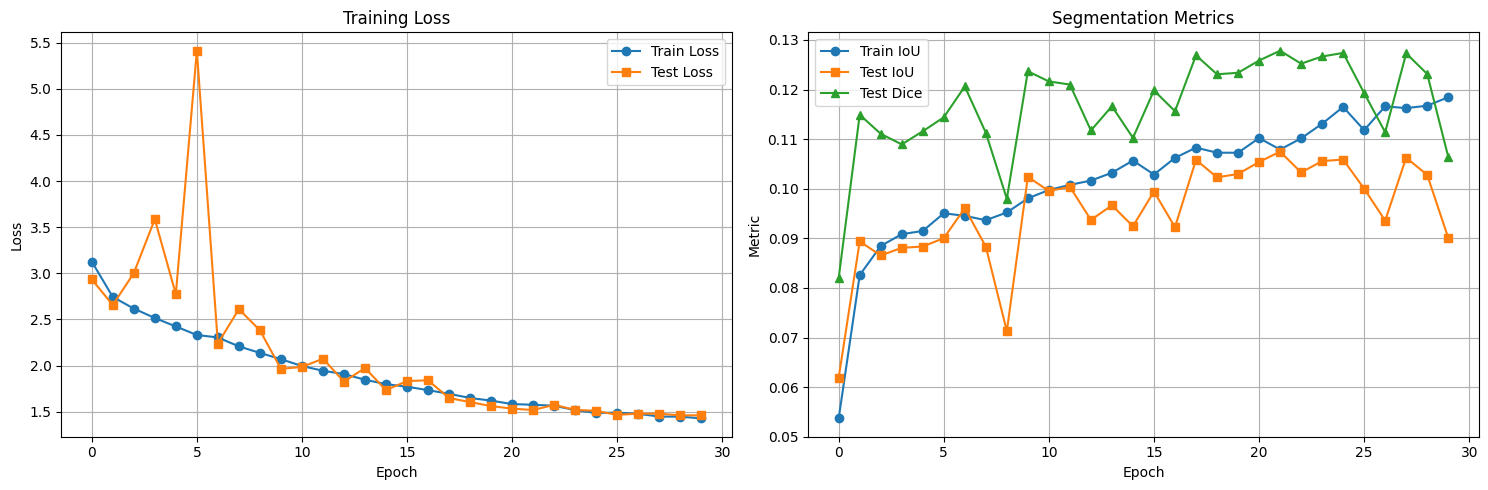


Final Test IoU: 0.0901
Final Test Dice: 0.1064


In [18]:
# Plot results
plot_segmentation_history(history)

print(f"\nFinal Test IoU: {history['test_iou'][-1]:.4f}")
print(f"Final Test Dice: {history['test_dice'][-1]:.4f}")

## Part 6: Visualize Results

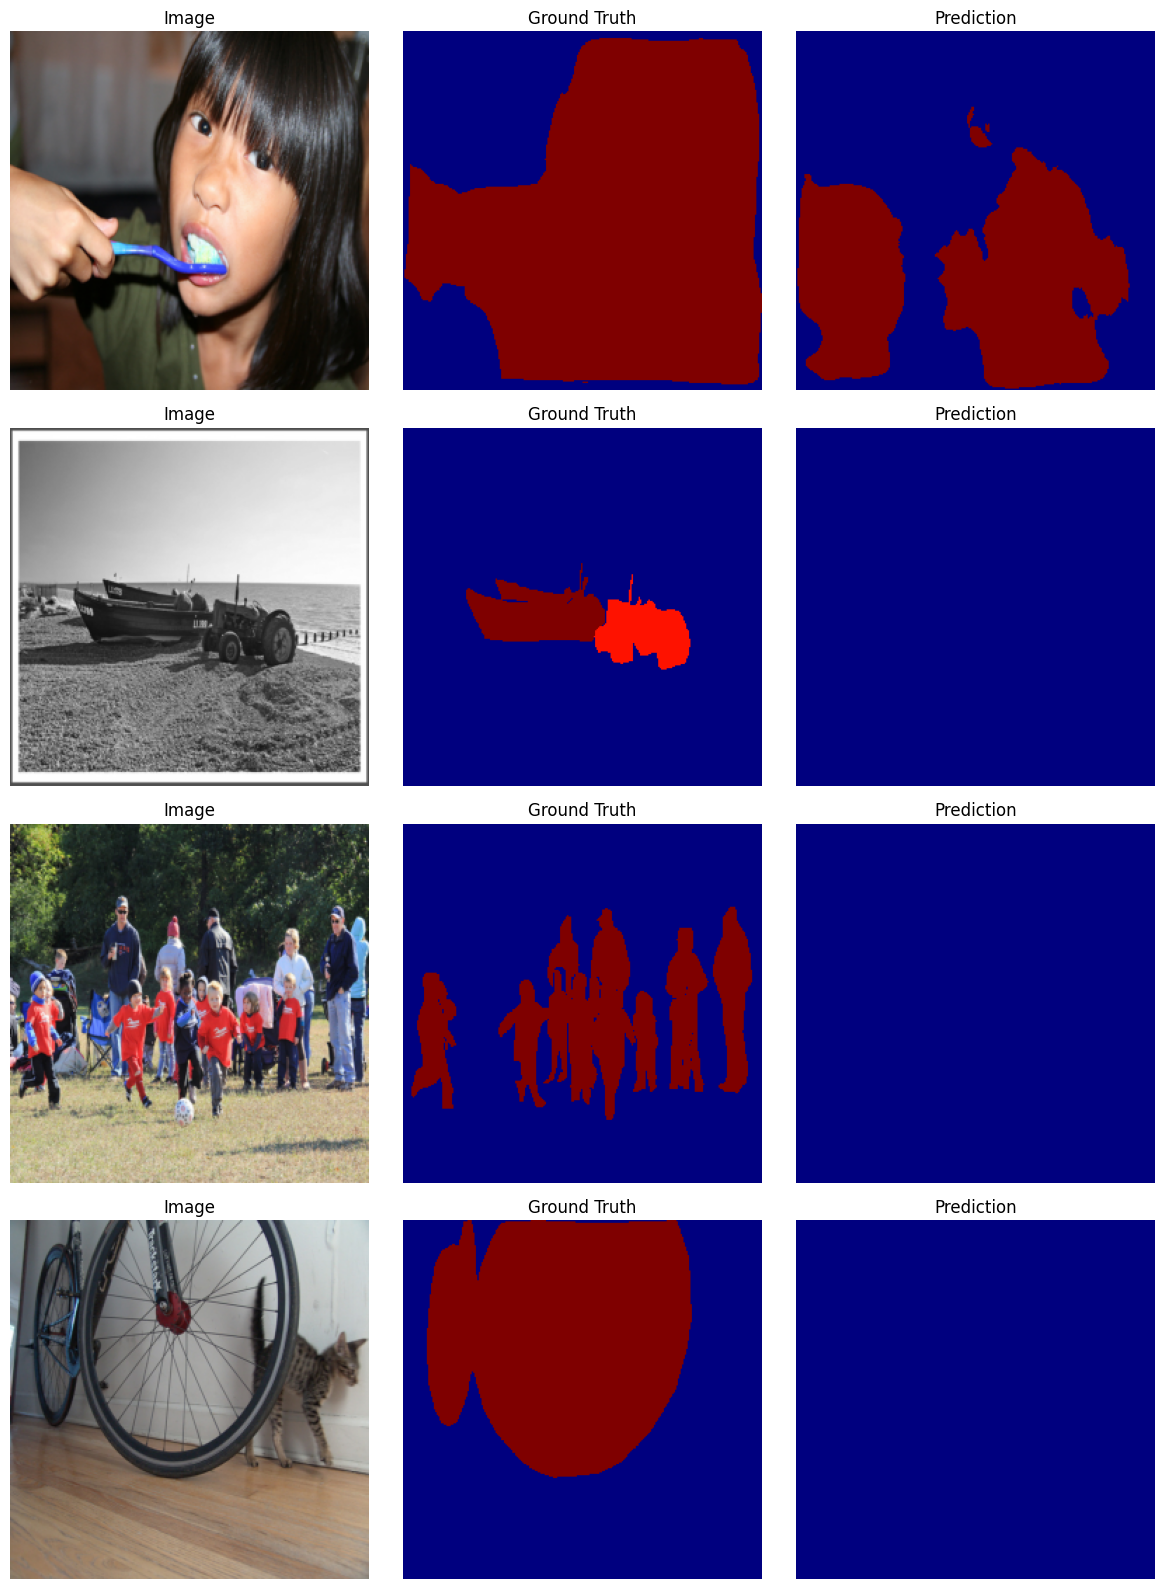

In [21]:
# Visualize predictions
model_unet.eval()

images, masks = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model_unet(images)
    predictions = torch.argmax(outputs, dim=1)

visualize_segmentation(images, masks, predictions, num_samples=4)

### Question 4: Results Analysis

**a) Analyze your segmentation results. What types of errors does the model make? (e.g., boundary errors, small object errors)**

$\color{blue}{\textit{Your Answer:}}$

It only worked for the first example, and even then it had boundary issues.

**b) How could you improve the segmentation performance? Suggest at least 3 techniques.**

$\color{blue}{\textit{Your Answer:}}$

1. Increase epochs
2. Increase the channels
3. Bilinear false

**c) Compare U-Net's performance on this task with what you might expect from a simple encoder-only CNN. Why is U-Net better suited for segmentation?**

$\color{blue}{\textit{Your Answer:}}$

It is better suited since there is heavy class imbalance.

In [20]:
# Advanced augmentation for segmentation
# Note: Both image and mask must undergo the same spatial transforms

import torchvision.transforms.functional as TF
import random

class SegmentationTransform:
    """
    Apply consistent transforms to both image and mask
    """

    def __init__(self, image_size=256):
        self.image_size = image_size

    def __call__(self, image, mask):
        # Resize
        image = TF.resize(image, self.image_size)
        mask = TF.resize(mask, self.image_size, interpolation=Image.NEAREST)

        # Random horizontal flip
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        # Random vertical flip
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        # Random rotation
        if random.random() > 0.5:
            angle = random.randint(-30, 30)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle, interpolation=Image.NEAREST)

        # Convert to tensor
        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)

        return image, mask

print("Advanced data augmentation for segmentation implemented.")
print("Key point: Apply the SAME spatial transforms to both image and mask!")

Advanced data augmentation for segmentation implemented.
Key point: Apply the SAME spatial transforms to both image and mask!


### Question 5: Advanced Concepts

**a) Why is data augmentation more complex for segmentation compared to classification?**

$\color{blue}{\textit{Your Answer:}}$

In segmentation, it is much more complex because you have mask image coherence.

**b) What modifications would you make to U-Net for multi-scale segmentation (objects of very different sizes)?**

$\color{blue}{\textit{Your Answer:}}$

Utilize the FPN, and maybe add some sort of attention gates.

**c) How would you modify U-Net for real-time segmentation applications? What trade-offs would you consider?**

$\color{blue}{\textit{Your Answer:}}$

Reduce decoder complexity to increase speed. This would decrease precision of the segmentation.